In [ ]:
!pip install duckdb -q
import pandas as pd
import duckdb

In [ ]:
# Este es el dataframe con el formato horizontal "sucio"
df_raw = pd.read_csv("A_B_testing_dataset.csv")
df_raw.head(2)

,date_of_campaign,facebook_ad_campaign,facebook_ad_views,facebook_ad_clicks,facebook_ad_conversions,facebook_cost_per_ad,facebook_ctr,facebook_conversion_rate,facebook_cost_per_click,adword_ad_campaign,adword_ad_views,adword_ad_clicks,adword_ad_conversions,adword_cost_per_ad,adword_ctr,adword_conversion_rate,adword_cost_per_click
0,2021-12-22,FACEBOOK AD,3172,62,14,141,1.95,22.58,2.27,ADWORD AD,5754,64,9,177,1.11,14.06,2.77
1,2021-12-24,FACEBOOK AD,3211,38,9,186,1.18,23.68,4.89,ADWORD AD,4954,73,6,54,1.47,8.22,0.74


In [ ]:
# Creamos la conexión de DuckDB
conn = duckdb.connect()

query = """
WITH vertical_data AS (
    -- Unificamos la parte de Facebook
    SELECT
        date_of_campaign AS date,
        'Facebook' AS platform,
        facebook_ad_views AS impressions,
        facebook_ad_clicks AS clicks,
        facebook_ad_conversions AS conversions,
        facebook_cost_per_ad AS spend
    FROM df_raw

    UNION ALL

    -- Unificamos la parte de AdWords
    SELECT
        date_of_campaign AS date,
        'AdWords' AS platform,
        adword_ad_views AS impressions,
        adword_ad_clicks AS clicks,
        adword_ad_conversions AS conversions,
        adword_cost_per_ad AS spend
    FROM df_raw
)
SELECT
    CAST(date AS DATE) AS campaign_date,
    platform,
    SUM(impressions) AS total_impressions,
    SUM(clicks) AS total_clicks,
    SUM(conversions) AS total_conversions,
    SUM(spend) AS total_spend,

    -- Métricas calculadas con mejores prácticas de SQL (evitando división por cero)
    ROUND(SUM(clicks)::NUMERIC / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions)::NUMERIC / NULLIF(SUM(clicks), 0), 4) AS conversion_rate,
    ROUND(SUM(spend)::NUMERIC / NULLIF(SUM(clicks), 0), 2) AS cpc,
    ROUND(SUM(spend)::NUMERIC / NULLIF(SUM(conversions), 0), 2) AS cpa
FROM vertical_data
GROUP BY 1, 2
ORDER BY 1 ASC, 2 DESC;
"""

# Ejecutamos el query de SQL y el resultado lo guardamos DIRECTO en un DataFrame de Pandas
df_clean = conn.execute(query).df()
df_clean.head()

,campaign_date,platform,total_impressions,total_clicks,total_conversions,total_spend,ctr,conversion_rate,cpc,cpa
0,2021-12-22,Facebook,3172.0,62.0,14.0,141.0,0.0195,0.2258,2.27,10.07
1,2021-12-22,AdWords,5754.0,64.0,9.0,177.0,0.0111,0.1406,2.77,19.67
2,2021-12-24,Facebook,3211.0,38.0,9.0,186.0,0.0118,0.2368,4.89,20.67
3,2021-12-24,AdWords,4954.0,73.0,6.0,54.0,0.0147,0.0822,0.74,9.00
4,2021-12-25,Facebook,3130.0,98.0,24.0,137.0,0.0313,0.2449,1.40,5.71


In [ ]:
import statsmodels.api as sm
import numpy as np

print("--- 1. Z-TEST PARA CONVERSION RATE ---")

conversiones_fb = df_clean[df_clean['platform'] == 'Facebook']['total_conversions'].sum()
clicks_fb = df_clean[df_clean['platform'] == 'Facebook']['total_clicks'].sum()

conversiones_aw = df_clean[df_clean['platform'] == 'AdWords']['total_conversions'].sum()
clicks_aw = df_clean[df_clean['platform'] == 'AdWords']['total_clicks'].sum()

exitos = np.array([conversiones_fb, conversiones_aw])
intentos = np.array([clicks_fb, clicks_aw])

z_stat, p_value_cr = sm.stats.proportions_ztest(exitos, intentos, alternative='two-sided')

ci_low, ci_high = sm.stats.proportion_confint(exitos, intentos, alpha=0.05)

print(f"Conversiones FB: {conversiones_fb} de {clicks_fb} clicks (CR: {(conversiones_fb/clicks_fb)*100:.2f}%)")
print(f"Conversiones AdWords: {conversiones_aw} de {clicks_aw} clicks (CR: {(conversiones_aw/clicks_aw)*100:.2f}%)")
print(f"Z-statistic: {z_stat:.4f} | P-value: {p_value_cr:.4f}")

--- 1. Z-TEST PARA CONVERSION RATE ---
Conversiones FB: 11975.0 de 44196.0 clicks (CR: 27.10%)
Conversiones AdWords: 5933.0 de 60128.0 clicks (CR: 9.87%)
Z-statistic: 72.9179 | P-value: 0.0000


In [ ]:


print("--- 1B. Z-TEST PARA CTR ---")

clicks_fb = df_clean[df_clean['platform'] == 'Facebook']['total_clicks'].sum()
impresiones_fb = df_clean[df_clean['platform'] == 'Facebook']['total_impressions'].sum()

clicks_aw = df_clean[df_clean['platform'] == 'AdWords']['total_clicks'].sum()
impresiones_aw = df_clean[df_clean['platform'] == 'AdWords']['total_impressions'].sum()

exitos = np.array([clicks_fb, clicks_aw])
intentos = np.array([impresiones_fb, impresiones_aw])

z_stat, p_value_ctr = sm.stats.proportions_ztest(exitos, intentos, alternative='two-sided')

ci_low, ci_high = sm.stats.proportion_confint(exitos, intentos, alpha=0.05)

print(f"Clicks FB: {clicks_fb} de {impresiones_fb} impresiones (CTR: {(clicks_fb/impresiones_fb)*100:.2f}%)")
print(f"Clicks AdWords: {clicks_aw} de {impresiones_aw} impresiones (CTR: {(clicks_aw/impresiones_aw)*100:.2f}%)")
print(f"Z-statistic: {z_stat:.4f} | P-value: {p_value_ctr:.4f}")

--- 1B. Z-TEST PARA CTR ---
Clicks FB: 44196.0 de 2152031.0 impresiones (CTR: 2.05%)
Clicks AdWords: 60128.0 de 4771438.0 impresiones (CTR: 1.26%)
Z-statistic: 79.3255 | P-value: 0.0000


In [ ]:
from scipy import stats

print("--- 2. WELCH'S T-TEST PARA CPA DIARIO ---")

# 1. Separamos las series de CPA diario por plataforma
cpa_diario_fb = df_clean[df_clean['platform'] == 'Facebook']['cpa'].dropna()
cpa_diario_aw = df_clean[df_clean['platform'] == 'AdWords']['cpa'].dropna()

# 2. Ejecutamos el T-Test de Welch
t_stat, p_value_cpa = stats.ttest_ind(cpa_diario_fb, cpa_diario_aw, equal_var=False)

print(f"CPA Medio Diario - Facebook: ${cpa_diario_fb.mean():.2f}")
print(f"CPA Medio Diario - AdWords: ${cpa_diario_aw.mean():.2f}")
print(f"Welch's T-statistic: {t_stat:.4f} | P-value: {p_value_cpa:.4f}")

--- 2. WELCH'S T-TEST PARA CPA DIARIO ---
CPA Medio Diario - Facebook: $14.81
CPA Medio Diario - AdWords: $23.31
Welch's T-statistic: -16.0816 | P-value: 0.0000


--- 3. VERIFICACIÓN DE SUPUESTOS (NORMALIDAD) ---
Shapiro-Wilk P-value (Facebook CPA): 0.0000
Shapiro-Wilk P-value (AdWords CPA): 0.0000


/tmp/ipykernel_16515/4008766505.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cpa_diario_fb, shade=True, color="blue", label="Facebook CPA")
/tmp/ipykernel_16515/4008766505.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cpa_diario_aw, shade=True, color="orange", label="AdWords CPA")


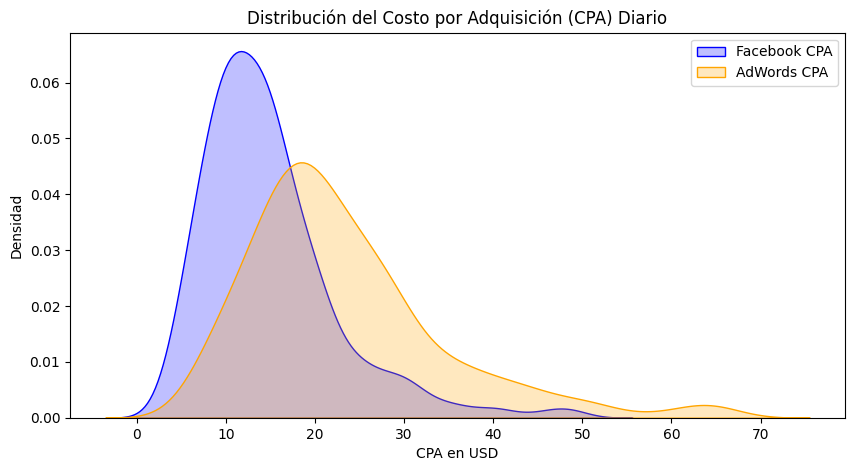

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 3. VERIFICACIÓN DE SUPUESTOS (NORMALIDAD) ---")

# Prueba formal de Shapiro-Wilk (Si p > 0.05, los datos son normales)
shapiro_fb = stats.shapiro(cpa_diario_fb)
shapiro_aw = stats.shapiro(cpa_diario_aw)

print(f"Shapiro-Wilk P-value (Facebook CPA): {shapiro_fb.pvalue:.4f}")
print(f"Shapiro-Wilk P-value (AdWords CPA): {shapiro_aw.pvalue:.4f}")

# Gráfico de Densidad para el reporte visual
plt.figure(figsize=(10, 5))
sns.kdeplot(cpa_diario_fb, shade=True, color="blue", label="Facebook CPA")
sns.kdeplot(cpa_diario_aw, shade=True, color="orange", label="AdWords CPA")
plt.title("Distribución del Costo por Adquisición (CPA) Diario")
plt.xlabel("CPA en USD")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [ ]:
from scipy import stats

print("--- 4. MANN-WHITNEY U TEST (VALIDACIÓN NO PARAMÉTRICA) ---")

u_stat, p_value_mw = stats.mannwhitneyu(cpa_diario_fb, cpa_diario_aw, alternative='two-sided')

print(f"Mann-Whitney U-statistic: {u_stat:.4f}")
print(f"P-value: {p_value_mw:.4f}")

if p_value_mw < 0.05:
    print("→ La diferencia en CPA entre plataformas es estadísticamente significativa (p < 0.05)")
else:
    print("→ No hay diferencia estadísticamente significativa en CPA entre plataformas")

--- 4. MANN-WHITNEY U TEST (VALIDACIÓN NO PARAMÉTRICA) ---
Mann-Whitney U-statistic: 103036.0000
P-value: 0.0000
→ La diferencia en CPA entre plataformas es estadísticamente significativa (p < 0.05)


In [ ]:

# 1. Cargar el archivo original que subiste a Colab
df_raw = pd.read_csv("A_B_testing_dataset.csv")

# 2. Conectar DuckDB para hacer la magia de SQL
conn = duckdb.connect()

# 3. El query definitivo que transforma, limpia y calcula todo
query = """
WITH data_vertical AS (
    -- Extraemos la parte de Facebook
    SELECT
        date_of_campaign AS date,
        'Facebook Ads' AS platform,
        facebook_ad_views AS impressions,
        facebook_ad_clicks AS clicks,
        facebook_ad_conversions AS conversions,
        facebook_cost_per_ad AS spend
    FROM df_raw

    UNION ALL

    -- Extraemos la parte de AdWords
    SELECT
        date_of_campaign AS date,
        'Google AdWords' AS platform,
        adword_ad_views AS impressions,
        adword_ad_clicks AS clicks,
        adword_ad_conversions AS conversions,
        adword_cost_per_ad AS spend
    FROM df_raw
)
SELECT
    CAST(date AS DATE) AS campaign_date,
    platform,
    SUM(impressions) AS total_impressions,
    SUM(clicks) AS total_clicks,
    SUM(conversions) AS total_conversions,
    SUM(spend) AS total_spend,

    -- Dejamos las métricas listas y redondeadas desde el pipeline
    ROUND(SUM(clicks)::NUMERIC / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions)::NUMERIC / NULLIF(SUM(clicks), 0), 4) AS conversion_rate,
    ROUND(SUM(spend)::NUMERIC / NULLIF(SUM(clicks), 0), 2) AS cpc,
    ROUND(SUM(spend)::NUMERIC / NULLIF(SUM(conversions), 0), 2) AS cpa
FROM data_vertical
GROUP BY 1, 2
ORDER BY 1 ASC, 2 DESC;
"""

# 4. Ejecutar el query y guardarlo en un DataFrame limpio
df_tableau = conn.execute(query).df()

# 5. Exportar el archivo final a la barra lateral de Colab
df_tableau.to_csv("AB_tableau.csv", index=False)

print("¡Listo! El archivo 'AB_tableau.csv' se ha generado con éxito.")

¡Listo! El archivo 'AB_tableau.csv' se ha generado con éxito.
